In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
%matplotlib inline
os.getcwd()
file = '../Scenario_Analysis.xlsx'
df = pd.read_excel(file, sheet_name='MethanolMarginal')
df = df.loc[:, ~df.columns.str.contains(r'\.\d+$')]
df = df.set_index(df.columns[0])

In [3]:
df

,Baseline,NoStorageCO2,NoStorageALL,H2,BioFixed,CO2Trans,ElectricityPrice
Week,,,,,,,
1,804.684724,805.604181,785.620320,804.684724,694.831918,815.391924,52.307083
2,800.044529,801.603149,673.613179,800.044529,692.795933,810.751729,55.798036
3,855.730538,855.259044,813.982168,855.730538,742.611611,866.437738,69.363512
4,880.787615,890.001913,917.569386,880.787615,769.272388,891.494815,74.571190
5,751.053644,755.109174,733.660529,751.053644,646.907438,761.760844,66.711369
6,684.800449,686.198746,680.437746,712.416516,581.154050,695.606880,51.036548
7,653.673288,660.137862,637.119455,708.226235,554.786144,664.412472,57.284167
8,655.584645,660.522362,634.238955,710.644310,555.498851,666.323828,55.897738
9,658.100592,662.812759,685.768622,708.456503,562.030293,668.841937,48.601012


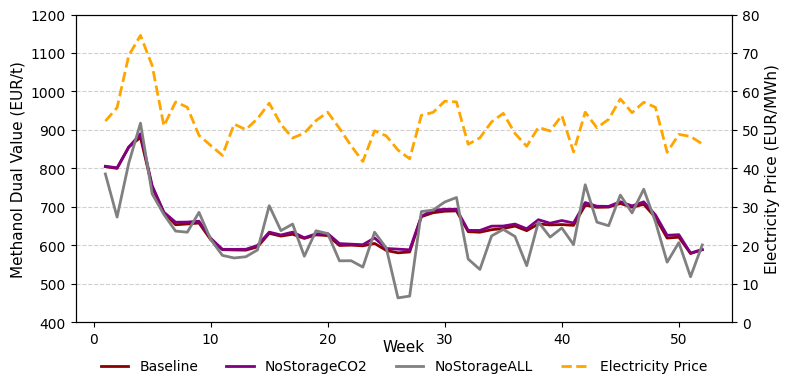

In [4]:
import matplotlib.pyplot as plt

def plot_weekly_methanol(df, scenarios, scenario_colors=None):
    if scenario_colors is None:
        scenario_colors = {}

    fig, ax1 = plt.subplots(figsize=(8, 4))

    # --- Plot scenarios on primary axis ---
    for scen in scenarios:
        ax1.plot(
            df.index,
            df[scen],
            label=scen,
            linewidth=2,
            color=scenario_colors.get(scen, None)
        )

    ax1.set_xlabel("Week", fontsize=11, labelpad=-5)
    ax1.set_ylabel("Methanol Dual Value (EUR/t)", fontsize=11)
    # ax1.set_title("Weekly Methanol Dual Value & Electricity Price", fontsize=12)
    ax1.set_ylim(400, 1200)

    ax1.grid(axis="y", linestyle="--", alpha=0.6)
    ax1.set_axisbelow(True)

    # --- Secondary axis for electricity price ---
    ax2 = ax1.twinx()
    ax2.plot(
        df.index,
        df["ElectricityPrice"],
        color="orange",
        linestyle="--",
        linewidth=2,
        label="Electricity Price"
    )
    ax2.set_ylim(0, 80)
    ax2.set_ylabel("Electricity Price (EUR/MWh)", fontsize=11)

    # --- Combined legend ---
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=len(scenarios) + 1,
        frameon=False,
        fontsize=10
    )

    fig.tight_layout()
    return fig  # <-- IMPORTANT: return figure (don’t show here)


# -------------------- One cell usage --------------------
scenario_colors = {
    "Baseline":     "darkred",
    "NoStorageCO2": "purple",
    "NoStorageALL": "gray",
    "H2":           "royalblue",
    "BioFixed":     "green",
    "CO2Trans":     "darkorange"
}

# scenarios = ["Baseline", "H2", "BioFixed", "CO2Trans"]
scenarios = ["Baseline", "NoStorageCO2", "NoStorageALL"]

fig = plot_weekly_methanol(df, scenarios, scenario_colors)

# fig.savefig("MethanolDualWeekly1.pdf", format="pdf", bbox_inches="tight")
fig.savefig("MethanolDualWeekly2.pdf", format="pdf", bbox_inches="tight")
plt.show()


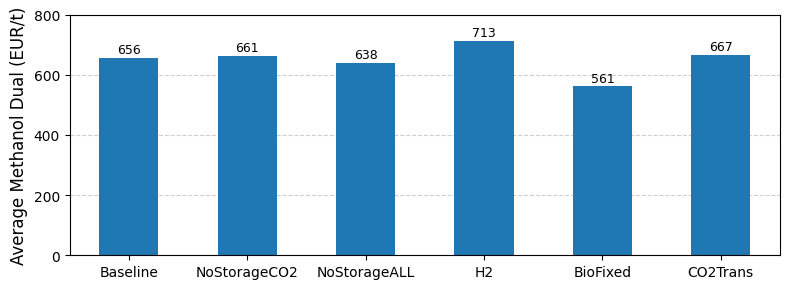

In [16]:
import matplotlib.pyplot as plt

# Select only scenario columns (exclude ElectricityPrice)
scenario_cols = [c for c in df.columns if c != "ElectricityPrice"]

# Compute averages
scenario_means = df[scenario_cols].mean().round(0)

fig, ax = plt.subplots(figsize=(8,3))

scenario_means.plot(kind='bar', ax=ax)

# Labels & title
ax.set_ylabel("Average Methanol Dual (EUR/t)", fontsize=12)
# ax.set_title("Average Weekly Methanol Dual per Scenario")

# Grid behind bars
ax.grid(axis='y', alpha=0.6, linestyle='--')
ax.set_axisbelow(True)

# X & Y ticks
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
ax.set_yticks(range(0, int(scenario_means.max()) + 100, 200))

# Numeric labels on bars
for i, value in enumerate(scenario_means):
    ax.text(
        i,
        value + (value * 0.01),
        f"{int(value)}",
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.savefig("MethanolDualAverage.pdf", format="pdf", bbox_inches="tight")
plt.show()


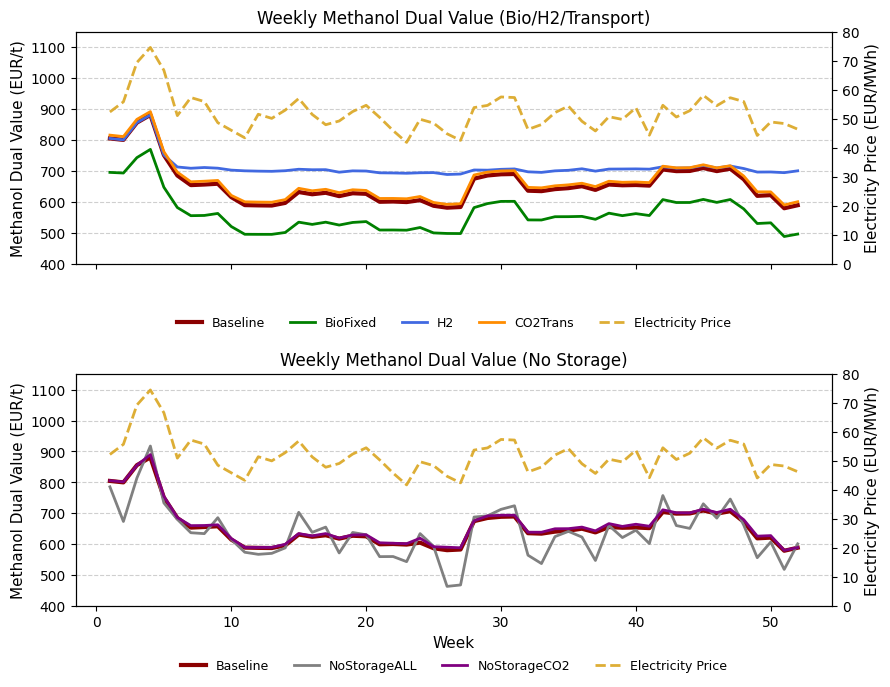

In [6]:
import matplotlib.pyplot as plt

def plot_weekly_methanol_subplots(df, scenario_colors=None):
    if scenario_colors is None:
        scenario_colors = {}

    # --- Define subplot scenario sets ---
    subplot1 = ["Baseline", "BioFixed", "H2", "CO2Trans"]
    subplot2 = ["Baseline", "NoStorageALL", "NoStorageCO2"]

    # --- Create figure with 2 subplots ---
    fig, axes = plt.subplots(
        nrows=2, ncols=1,
        figsize=(9, 7),
        sharex=True
    )

    methanol_ylim = (400, 1150)
    elec_ylim = (0, 80)

    def draw_panel(ax, scenarios, panel_title):
        # --- Methanol dual values (primary axis) ---
        for scen in scenarios:
            lw = 3 if scen == "Baseline" else 2  # baseline thicker
            ax.plot(
                df.index,
                df[scen],
                linewidth=lw,
                color=scenario_colors.get(scen, None),
                label=scen
            )

        ax.set_ylabel("Methanol Dual Value (EUR/t)", fontsize=11)
        ax.set_ylim(*methanol_ylim)
        ax.set_title(panel_title, fontsize=12)
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        ax.set_axisbelow(True)

        # --- Electricity price (secondary axis) ---
        ax2 = ax.twinx()
        ax2.plot(
            df.index,
            df["ElectricityPrice"],
            color="goldenrod",
            linestyle="--",
            linewidth=2,
            alpha=0.9,
            label="Electricity Price"
        )

        ax2.set_ylim(*elec_ylim)
        ax2.set_ylabel("Electricity Price (EUR/MWh)", fontsize=11)

        # --- Combined legend for this subplot ---
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()

        ax.legend(
            lines1 + lines2,
            labels1 + labels2,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.18),
            ncol=len(labels1 + labels2),
            frameon=False,
            fontsize=9
        )

    # --- Draw panels ---
    draw_panel(axes[0], subplot1, "Weekly Methanol Dual Value (Bio/H2/Transport)")
    draw_panel(axes[1], subplot2, "Weekly Methanol Dual Value (No Storage)")

    axes[1].set_xlabel("Week", fontsize=11)

    fig.tight_layout()
    return fig


# -------------------- One cell usage --------------------
scenario_colors = {
    "Baseline":     "darkred",
    "NoStorageCO2": "purple",
    "NoStorageALL": "gray",
    "H2":           "royalblue",
    "BioFixed":     "green",
    "CO2Trans":     "darkorange"
}

fig = plot_weekly_methanol_subplots(df, scenario_colors)

fig.savefig("MethanolDualWeekly_Subplots.pdf", format="pdf", bbox_inches="tight")
plt.show()


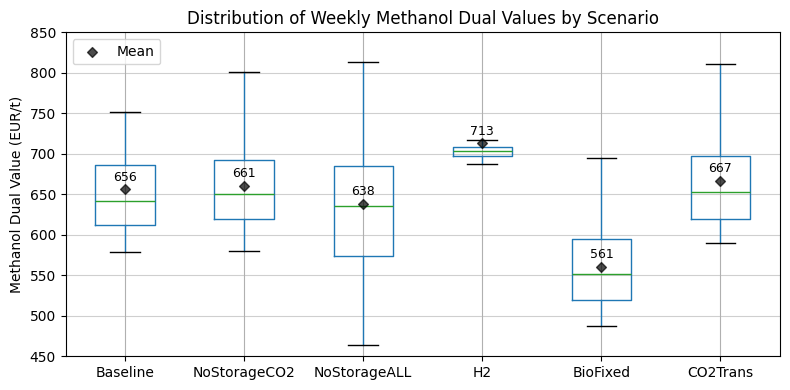

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# --- Select only scenario columns ---
scenario_cols = [c for c in df.columns if c != "ElectricityPrice"]

fig, ax = plt.subplots(figsize=(8,4))

# --- Boxplot ---
df[scenario_cols].boxplot(
    ax=ax,
    showfliers=False
)

# --- Compute means ---
means = df[scenario_cols].mean()
x_positions = np.arange(1, len(means) + 1)

# --- Add mean markers (small + subtle) ---
ax.scatter(
    x_positions,
    means,
    marker="D",
    s=25,            # small size
    color="black",
    alpha=0.7,
    label="Mean",
    zorder=3
)

# --- Label mean values ---
for x, mean in zip(x_positions, means):
    ax.annotate(
        f"{mean:.0f}",
        (x, mean),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=9
    )

# --- Labels & styling ---
ax.set_ylabel("Methanol Dual Value (EUR/t)")
ax.set_title("Distribution of Weekly Methanol Dual Values by Scenario")

ax.grid(axis="y", alpha=0.6)
ax.set_axisbelow(True)

ax.set_ylim(450, 850)

plt.xticks(rotation=0)
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("MethanolDual_Boxplot.pdf", bbox_inches="tight")
plt.show()
